In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

ticker = yf.download("KO", period="10y")
index = yf.download("SPY", period="10y")
vix = yf.download("^VIX", period="10y")
ticker["Returns"] = ticker["Close"].pct_change()

ticker["SMA_10"] = ticker["Close"].rolling(10).mean()
ticker["SMA_20"] = ticker["Close"].rolling(10).mean()
ticker["SMA_50"] = ticker["Close"].rolling(50).mean()
ticker["EMA_10"] = ticker["Close"].ewm(span=10, adjust=False).mean()
ticker["EMA_20"] = ticker["Close"].ewm(span=20, adjust=False).mean()
ticker["EMA_50"] = ticker["Close"].ewm(span=50, adjust=False).mean()

ticker["Index SMA_10"] = index["Close"].rolling(10).mean()
ticker["Index SMA_20"] = index["Close"].rolling(10).mean()
ticker["Index SMA_50"] = index["Close"].rolling(50).mean()
ticker["Index EMA_10"] = index["Close"].ewm(span=10, adjust=False).mean()
ticker["Index EMA_20"] = index["Close"].ewm(span=20, adjust=False).mean()
ticker["Index EMA_50"] = index["Close"].ewm(span=50, adjust=False).mean()

ticker["Vol_10"] = ticker["Returns"].rolling(window=10).std() * np.sqrt(252)
ticker["Vol_20"] = ticker["Returns"].rolling(window=20).std() * np.sqrt(252)
ticker["Vol_50"] = ticker["Returns"].rolling(window=50).std() * np.sqrt(252)

days = 4
for i in range(1, days + 1):
    ticker[f"Close_lag_{i}"] = ticker["Close"].shift(i)

ticker.dropna(inplace=True)
print(ticker.head())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['KO']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['SPY']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['^VIX']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


Empty DataFrame
Columns: [(Adj Close, KO), (Close, KO), (High, KO), (Low, KO), (Open, KO), (Volume, KO), (Returns, ), (SMA_10, ), (SMA_20, ), (SMA_50, ), (EMA_10, ), (EMA_20, ), (EMA_50, ), (Index SMA_10, ), (Index SMA_20, ), (Index SMA_50, ), (Index EMA_10, ), (Index EMA_20, ), (Index EMA_50, ), (Vol_10, ), (Vol_20, ), (Vol_50, ), (Close_lag_1, ), (Close_lag_2, ), (Close_lag_3, ), (Close_lag_4, )]
Index: []

[0 rows x 26 columns]


In [65]:
ticker_dnn = ticker.copy()
ticker_dnn["Next Close"] = ticker_dnn["Close"].shift(-1)
ticker_dnn.drop(columns=["Open", "High", "Low"], inplace=True)
ticker_dnn.dropna(inplace=True)

y = ticker_dnn["Next Close"].values
X = ticker_dnn.drop(columns=["Next Close"])
print(X.shape)

(2465, 22)


In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

train_start = int(len(X) * 0.6)
val_start = int(len(X) * 0.8)


X_train = X[:train_start]
X_val = X[train_start:val_start]
X_test = X[val_start:]
y_train = y[:train_start]
y_val = y[train_start:val_start]
y_test = y[val_start:]
print(X_train.shape, X_val.shape, X_test.shape)

(1479, 22) (493, 22) (493, 22)


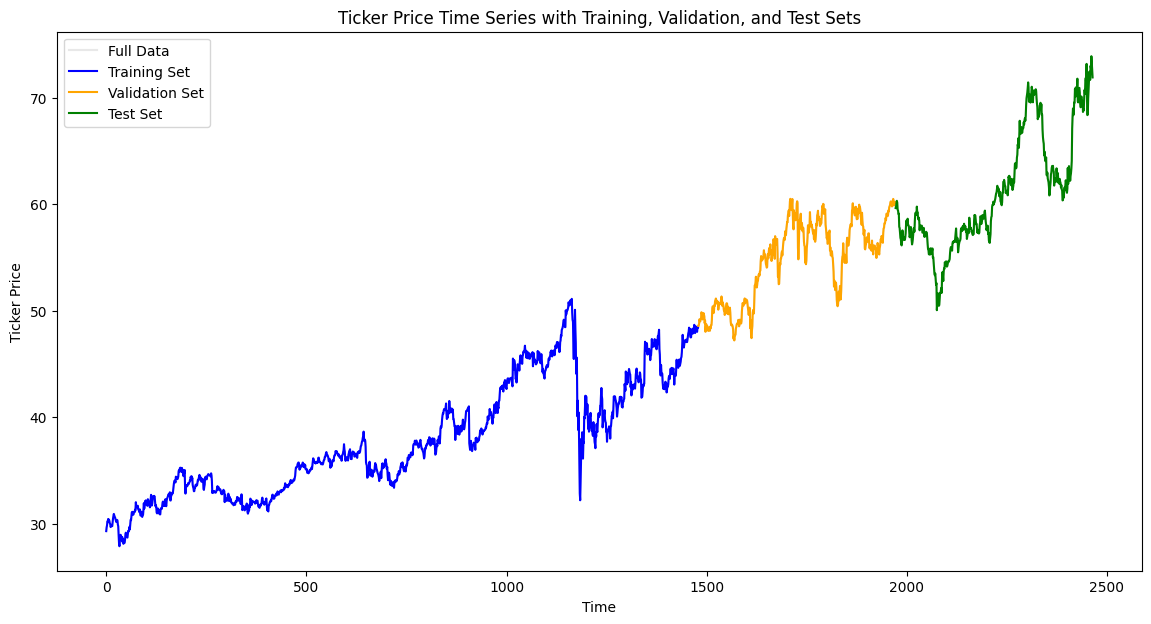

In [67]:
plt.figure(figsize=(14, 7))
plt.plot(range(len(y)), y, label='Full Data', color='lightgrey', alpha=0.5)

# Plot Training Data
plt.plot(range(len(y_train)), y_train, label='Training Set', color='blue')

# Plot Validation Data
plt.plot(range(len(y_train), len(y_train) + len(y_val)), y_val, label='Validation Set', color='orange')

# Plot Test Data
plt.plot(range(len(y_train) + len(y_val), len(y_train) + len(y_val) + len(y_test)), y_test, label='Test Set', color='green')

# Add title and labels
plt.title('Ticker Price Time Series with Training, Validation, and Test Sets')
plt.xlabel('Time')
plt.ylabel('Ticker Price')
plt.legend()

# Show the plot
plt.show()

In [68]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_data = TensorDataset(X_train_tensor, y_train_tensor)
val_data = TensorDataset(X_val_tensor, y_val_tensor)
test_data = TensorDataset(X_test_tensor, y_test_tensor)

# train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
# val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
# test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [69]:
class PricePredictorDNN(nn.Module):
    def __init__(self, input_size, dropout_rate=0.2):
        super(PricePredictorDNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(256, 128)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.fc3 = nn.Linear(128, 128)
        self.dropout3 = nn.Dropout(dropout_rate)
        self.fc4 = nn.Linear(128, 64)
        self.dropout4 = nn.Dropout(dropout_rate)
        self.fc5 = nn.Linear(64, 32)
        self.fc6 = nn.Linear(32, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        x = self.dropout3(x)
        x = torch.relu(self.fc4(x))
        x = self.dropout4(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        return x

# Initialize the model
model = PricePredictorDNN(input_size=X_train.shape[1])

In [70]:
def train_model(model, train_loader, val_loader, criterion, optimizer, lambda_l1, epochs=100, device='cpu'):
    train_loss_list = []
    val_loss_list = []

    for epoch in range(epochs):
        model.train()  # Set model to training mode
        train_loss = 0
        for batch in train_loader:
            X_batch, y_batch = batch
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # Move to device
            optimizer.zero_grad()  # Clear previous gradients
            output = model(X_batch)  # Forward pass
            loss = criterion(output, y_batch.view(-1, 1))  # Compute loss
            
            # L1 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            loss += lambda_l1 * l1_norm  # Add L1 penalty
            loss.backward()  # Backpropagate gradients
            optimizer.step()  # Update weights
            train_loss += loss.item()

        # Validation loss
        model.eval()  # Set model to evaluation mode
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                X_batch, y_batch = batch
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # Move to device
                output = model(X_batch)  # Forward pass (no gradients)
                loss = criterion(output, y_batch.view(-1, 1))  # Compute loss
                
                # L1 regularization
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss += lambda_l1 * l1_norm  # Add L1 penalty
                val_loss += loss.item()

        # Average the losses over batches
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)

        train_loss_list.append(train_loss)
        val_loss_list.append(val_loss)

        print(f'Epoch {epoch+1}/{epochs}, Training Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}')

    return train_loss_list, val_loss_list

In [71]:
import optuna
from torch.utils.data import Dataset

class CustomDataset(Dataset):
    def __init__(self, X, y):
        """
        X: Input features (e.g., a tensor of shape [n_samples, n_features])
        y: Target labels (e.g., a tensor of shape [n_samples, 1] or [n_samples])
        """
        self.X = X
        self.y = y

    def __len__(self):
        # Return the total number of samples in the dataset
        return len(self.X)

    def __getitem__(self, idx):
        # Return a single sample (input features and target label) at the given index
        return self.X[idx], self.y[idx]
    
train_dataset = CustomDataset(X_train_tensor, y_train_tensor)
val_dataset = CustomDataset(X_val_tensor, y_val_tensor)

def evaluate_model(input_size, dropout_rate, lr, optimizer_name, loss_fn_name, batch_size, lambda_l1, train_dataset, val_dataset, device, trial):
    # Initialize the model
    model = PricePredictorDNN(input_size=input_size, dropout_rate=dropout_rate).to(device)

    # Select optimizer
    if optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "rmsprop":
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Unknown optimizer {optimizer_name}")

    # Select loss function
    if loss_fn_name == "mse":
        criterion = nn.MSELoss()
    elif loss_fn_name == "mae":
        criterion = nn.L1Loss()
    else:
        raise ValueError(f"Unknown loss function {loss_fn_name}")

    # Create DataLoader for training and validation
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Train the model
    train_loss_list, val_loss_list = train_model(
        model, 
        train_loader, 
        val_loader, 
        criterion, 
        optimizer, 
        lambda_l1, 
        epochs=100,  # Number of epochs
        device="cpu",
    )

    # Return the final validation loss (used for Optuna optimization)
    final_val_loss = val_loss_list[-1]
    return final_val_loss


def objective(trial):
    # Hyperparameters to tune
    lr = trial.suggest_loguniform('lr', 1e-5, 1e-2)
    dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop'])
    loss_fn_name = trial.suggest_categorical('loss_fn', ['mse', 'mae'])
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    lambda_l1 = trial.suggest_uniform('lambda_l1', 0.0, 0.01)


    # Call the evaluation function with the datasets and the current trial's hyperparameters
    val_loss = evaluate_model(
        input_size=X_train.shape[1],  # Set this to your input size
        dropout_rate=dropout_rate,
        lr=lr,
        optimizer_name=optimizer_name,
        loss_fn_name=loss_fn_name,
        batch_size=batch_size,
        lambda_l1=lambda_l1,
        train_dataset=train_dataset,  # Your train dataset here
        val_dataset=val_dataset,      # Your validation dataset here
        device="cpu",  # Device is passed here
        trial=trial
    )

    return val_loss


# Create Optuna study
study = optuna.create_study(direction='minimize')  # Minimize the validation loss
study.optimize(objective, n_trials=100)  # Perform optimization over 100 trials

# Output the best hyperparameters
print("Best hyperparameters:", study.best_params)


[I 2025-04-26 01:46:35,324] A new study created in memory with name: no-name-74ccd3b3-0739-4be4-ab5d-d3c5999bcbb7
/var/folders/12/hdw_ls8n7rs0lj0nn0x94wgc0000gn/T/ipykernel_40960/3553760737.py:69: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform('lr', 1e-5, 1e-2)
/var/folders/12/hdw_ls8n7rs0lj0nn0x94wgc0000gn/T/ipykernel_40960/3553760737.py:70: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
/var/folders/12/hdw_ls8n7rs0lj0nn0x94wgc0000gn/T/ipykernel_40960/3553760737.py:74: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optun

Epoch 1/100, Training Loss: inf, Validation Loss: nan
Epoch 2/100, Training Loss: nan, Validation Loss: nan
Epoch 3/100, Training Loss: nan, Validation Loss: nan
Epoch 4/100, Training Loss: nan, Validation Loss: nan
Epoch 5/100, Training Loss: nan, Validation Loss: nan
Epoch 6/100, Training Loss: nan, Validation Loss: nan
Epoch 7/100, Training Loss: nan, Validation Loss: nan
Epoch 8/100, Training Loss: nan, Validation Loss: nan
Epoch 9/100, Training Loss: nan, Validation Loss: nan
Epoch 10/100, Training Loss: nan, Validation Loss: nan
Epoch 11/100, Training Loss: nan, Validation Loss: nan
Epoch 12/100, Training Loss: nan, Validation Loss: nan
Epoch 13/100, Training Loss: nan, Validation Loss: nan
Epoch 14/100, Training Loss: nan, Validation Loss: nan
Epoch 15/100, Training Loss: nan, Validation Loss: nan
Epoch 16/100, Training Loss: nan, Validation Loss: nan
Epoch 17/100, Training Loss: nan, Validation Loss: nan
Epoch 18/100, Training Loss: nan, Validation Loss: nan
Epoch 19/100, Train

[W 2025-04-26 01:46:37,712] Trial 0 failed with parameters: {'lr': 0.0034802869069582316, 'dropout_rate': 0.1315818932264413, 'optimizer': 'sgd', 'loss_fn': 'mse', 'batch_size': 128, 'lambda_l1': 0.0006999041986970867} because of the following error: The value nan is not acceptable.
[W 2025-04-26 01:46:37,713] Trial 0 failed with value nan.


Epoch 100/100, Training Loss: nan, Validation Loss: nan
Epoch 1/100, Training Loss: 897.2535, Validation Loss: 1598.2279
Epoch 2/100, Training Loss: 282.6048, Validation Loss: 649.1563
Epoch 3/100, Training Loss: 152.0953, Validation Loss: 349.6877
Epoch 4/100, Training Loss: 120.7575, Validation Loss: 58.6768
Epoch 5/100, Training Loss: 108.3142, Validation Loss: 118.4890
Epoch 6/100, Training Loss: 105.2659, Validation Loss: 71.4956
Epoch 7/100, Training Loss: 98.7496, Validation Loss: 57.8868
Epoch 8/100, Training Loss: 95.1417, Validation Loss: 71.0577
Epoch 9/100, Training Loss: 92.8467, Validation Loss: 135.5143
Epoch 10/100, Training Loss: 89.3593, Validation Loss: 75.0539
Epoch 11/100, Training Loss: 81.1493, Validation Loss: 32.2709
Epoch 12/100, Training Loss: 78.5164, Validation Loss: 29.7071
Epoch 13/100, Training Loss: 75.5745, Validation Loss: 28.9220
Epoch 14/100, Training Loss: 83.0826, Validation Loss: 25.2251
Epoch 15/100, Training Loss: 79.4002, Validation Loss: 54.6

[I 2025-04-26 01:46:41,662] Trial 1 finished with value: 193.53515434265137 and parameters: {'lr': 0.0026013360594833346, 'dropout_rate': 0.45663326353881895, 'optimizer': 'adam', 'loss_fn': 'mse', 'batch_size': 64, 'lambda_l1': 0.008654840325345973}. Best is trial 1 with value: 193.53515434265137.


...

Epoch 99/100, Training Loss: 4.0111, Validation Loss: 6.4059
Epoch 100/100, Training Loss: 4.0899, Validation Loss: 4.6341
Epoch 1/100, Training Loss: 49.6510, Validation Loss: 66.5819
Epoch 2/100, Training Loss: 49.4629, Validation Loss: 66.4806
Epoch 3/100, Training Loss: 49.4710, Validation Loss: 66.3802
Epoch 4/100, Training Loss: 49.3784, Validation Loss: 66.2812
Epoch 5/100, Training Loss: 49.3668, Validation Loss: 66.1834
Epoch 6/100, Training Loss: 49.1138, Validation Loss: 66.0856
Epoch 7/100, Training Loss: 49.1148, Validation Loss: 65.9870
Epoch 8/100, Training Loss: 48.9082, Validation Loss: 65.8883
Epoch 9/100, Training Loss: 48.9335, Validation Loss: 65.7894
Epoch 10/100, Training Loss: 48.8278, Validation Loss: 65.6906
Epoch 11/100, Training Loss: 48.7185, Validation Loss: 65.5915
Epoch 12/100, Training Loss: 48.6787, Validation Loss: 65.4921
Epoch 13/100, Training Loss: 48.4607, Validation Loss: 65.3922
Epoch 14/100, Training Loss: 48.3854, Validation Loss: 65.2916
Epoc

[I 2025-04-26 01:53:58,943] Trial 98 finished with value: 11.491209149360657 and parameters: {'lr': 0.0018472758859296124, 'dropout_rate': 0.2933385328097178, 'optimizer': 'sgd', 'loss_fn': 'mae', 'batch_size': 64, 'lambda_l1': 0.004032217081795404}. Best is trial 34 with value: 2.0261251628398895.


Epoch 94/100, Training Loss: 11.7027, Validation Loss: 11.4788
Epoch 95/100, Training Loss: 11.4946, Validation Loss: 11.9033
Epoch 96/100, Training Loss: 11.5214, Validation Loss: 9.6434
Epoch 97/100, Training Loss: 11.5307, Validation Loss: 9.2876
Epoch 98/100, Training Loss: 11.3821, Validation Loss: 10.3812
Epoch 99/100, Training Loss: 11.3190, Validation Loss: 11.7450
Epoch 100/100, Training Loss: 11.3471, Validation Loss: 11.4912
Epoch 1/100, Training Loss: 44.3458, Validation Loss: 56.9800
Epoch 2/100, Training Loss: 38.3850, Validation Loss: 53.1721
Epoch 3/100, Training Loss: 24.1879, Validation Loss: 45.7573
Epoch 4/100, Training Loss: 16.7587, Validation Loss: 25.6853
Epoch 5/100, Training Loss: 12.9970, Validation Loss: 8.0641
Epoch 6/100, Training Loss: 12.2964, Validation Loss: 6.9461
Epoch 7/100, Training Loss: 11.3287, Validation Loss: 5.8776
Epoch 8/100, Training Loss: 11.1793, Validation Loss: 4.8065
Epoch 9/100, Training Loss: 10.9197, Validation Loss: 7.3611
Epoch 1

[I 2025-04-26 01:54:03,330] Trial 99 finished with value: 8.430862188339233 and parameters: {'lr': 0.0007221739413361941, 'dropout_rate': 0.46931348731661554, 'optimizer': 'rmsprop', 'loss_fn': 'mae', 'batch_size': 64, 'lambda_l1': 0.00568714747925625}. Best is trial 34 with value: 2.0261251628398895.


Epoch 96/100, Training Loss: 5.4567, Validation Loss: 10.7817
Epoch 97/100, Training Loss: 5.3601, Validation Loss: 9.8837
Epoch 98/100, Training Loss: 5.4544, Validation Loss: 9.9455
Epoch 99/100, Training Loss: 5.2364, Validation Loss: 7.4466
Epoch 100/100, Training Loss: 5.1504, Validation Loss: 8.4309
Best hyperparameters: {'lr': 0.0016027204499876571, 'dropout_rate': 0.47188423512716093, 'optimizer': 'rmsprop', 'loss_fn': 'mae', 'batch_size': 64, 'lambda_l1': 0.0037198177395463437}


In [72]:
best_params = study.best_params
best_model = PricePredictorDNN(input_size=X_train.shape[1], dropout_rate=best_params['dropout_rate'])
if best_params['optimizer'] == 'adam':
    optimizer = optim.Adam(model.parameters(), lr=best_params['lr'])
elif best_params['optimizer'] == 'sgd':
    optimizer = optim.SGD(model.parameters(), lr=best_params['lr'])
elif best_params['optimizer'] == 'rmsprop':
    optimizer = optim.RMSprop(model.parameters(), lr=best_params['lr'])

if best_params['loss_fn'] == 'mse':
    criterion = torch.nn.MSELoss()
elif best_params['loss_fn'] == 'mae':
    criterion = torch.nn.L1Loss()

test_dataset = CustomDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'], shuffle=False)

train_loss, val_loss = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    best_params['lambda_l1'],
    epochs=30,  # Number of epochs
    device="cpu"
)


Epoch 1/30, Training Loss: 29.1369, Validation Loss: 43.5118
Epoch 2/30, Training Loss: 13.5478, Validation Loss: 20.5258
Epoch 3/30, Training Loss: 10.3998, Validation Loss: 6.4443
Epoch 4/30, Training Loss: 9.2294, Validation Loss: 17.0067
Epoch 5/30, Training Loss: 8.5762, Validation Loss: 11.5844
Epoch 6/30, Training Loss: 8.2015, Validation Loss: 3.9279
Epoch 7/30, Training Loss: 7.7895, Validation Loss: 8.4104
Epoch 8/30, Training Loss: 7.4714, Validation Loss: 9.2705
Epoch 9/30, Training Loss: 7.4237, Validation Loss: 5.9647
Epoch 10/30, Training Loss: 7.0128, Validation Loss: 4.0680
Epoch 11/30, Training Loss: 6.6932, Validation Loss: 3.3697
Epoch 12/30, Training Loss: 6.8890, Validation Loss: 4.3575
Epoch 13/30, Training Loss: 7.0727, Validation Loss: 3.4294
Epoch 14/30, Training Loss: 6.7614, Validation Loss: 7.6012
Epoch 15/30, Training Loss: 6.0501, Validation Loss: 5.6134
Epoch 16/30, Training Loss: 6.4113, Validation Loss: 2.8587
Epoch 17/30, Training Loss: 6.0691, Valida

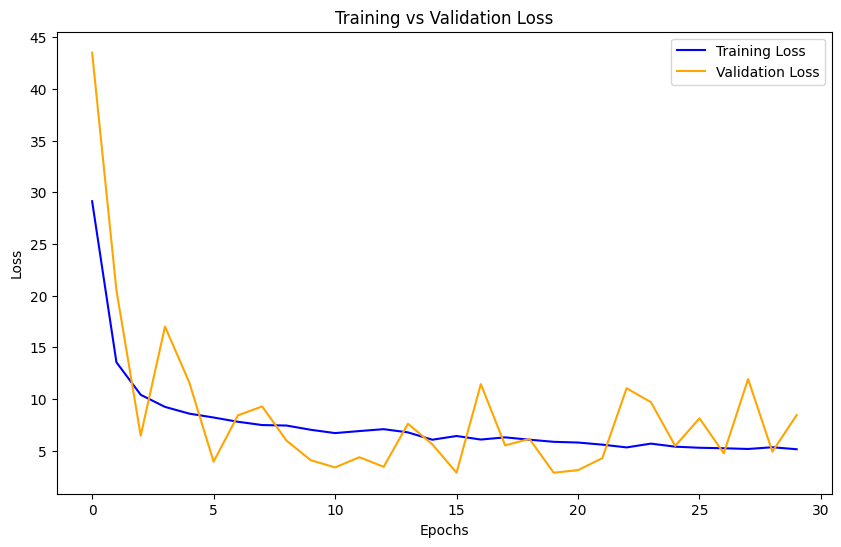

In [73]:
plt.figure(figsize=(10,6))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [74]:
# Evaluate the model on the test set
model.eval()  # Set model to evaluation mode
test_loss = 0
with torch.no_grad():
    for batch in test_loader:
        X_batch, y_batch = batch
        output = model(X_batch)  # Forward pass (no gradients)
        loss = criterion(output, y_batch.view(-1, 1))  # Compute loss
        test_loss += loss.item()

test_loss /= len(test_loader)
print(f'Test Loss: {test_loss:.4f}')

Test Loss: 7.7452


In [75]:
y_hat_test = model(X_test_tensor)
mse = torch.mean((y_hat_test - y_test_tensor.view(-1, 1)) ** 2)
rmse = torch.sqrt(mse)
print(f"Test MSE: {mse.item():.4f}")
print(f"Test RMSE: {rmse.item():.4f}")

Test MSE: 60.4580
Test RMSE: 7.7755


In [76]:
y_hat_test_na = y_hat_test.detach().numpy()
y_test_na = y_test_tensor.detach().numpy()

comparison_df = pd.DataFrame({
    'Predicted': y_hat_test_na.flatten(),  # Flatten in case of multidimensional arrays
    'Actual': y_test_na.flatten()
})

print(comparison_df)

     Predicted     Actual
0    52.309624  59.647282
1    52.151047  59.750790
2    52.077671  60.089535
3    52.107948  60.324772
4    52.195999  60.164810
..         ...        ...
488  62.294949  72.769997
489  62.881718  73.900002
490  63.368694  73.300003
491  63.567242  72.519997
492  63.537025  71.910004

[493 rows x 2 columns]


In [77]:
count = 0
correct_count = 0
for i in range(1, len(comparison_df) - 1):
    count += 1
    if(comparison_df["Predicted"][i] > comparison_df["Actual"][i - 1] and comparison_df["Actual"][i] > comparison_df["Actual"][i - 1]):
        correct_count += 1
    elif(comparison_df["Predicted"][i] < comparison_df["Actual"][i - 1] and comparison_df["Actual"][i] < comparison_df["Actual"][i - 1]):
        correct_count += 1

print(count)
print(correct_count)
print(f"Accuracy: {correct_count / count:.4f}")

491
226
Accuracy: 0.4603
